 In this problem, you will generate simulated data, and then perform
 PCA and K-means clustering on the data.

(a) Generate a simulated data set with 20 observations in each of
 three classes (i.e. 60 observations total), and 50 variables.
 Hint: There are a number of functions in Python that you can
 use to generate data. One example is the normal() method of
 the random() function in numpy; the uniform() method is another
 option. Be sure to add a mean shift to the observations in each
 class so that there are three distinct classes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

np.random.seed(42)

n_obs_per_class = 20  
n_classes = 3        
n_features = 50       

X_class1 = np.random.normal(loc=0, scale=1, size=(n_obs_per_class, n_features))
X_class2 = np.random.normal(loc=3, scale=1, size=(n_obs_per_class, n_features))
X_class3 = np.random.normal(loc=-3, scale=1, size=(n_obs_per_class, n_features))

X = np.vstack([X_class1, X_class2, X_class3])

y_true = np.array([1]*n_obs_per_class + [2]*n_obs_per_class + [3]*n_obs_per_class)

 (b) Perform PCA on the 60 observations and plot the first two prin
cipal component score vectors. Use a different color to indicate
 the observations in each of the three classes. If the three classes
 appear separated in this plot, then continue on to part (c). If
 not, then return to part (a) and modify the simulation so that
 there is greater separation between the three classes. Do not
 continue to part (c) until the three classes show at least some
 separation in the first two principal component score vectors.

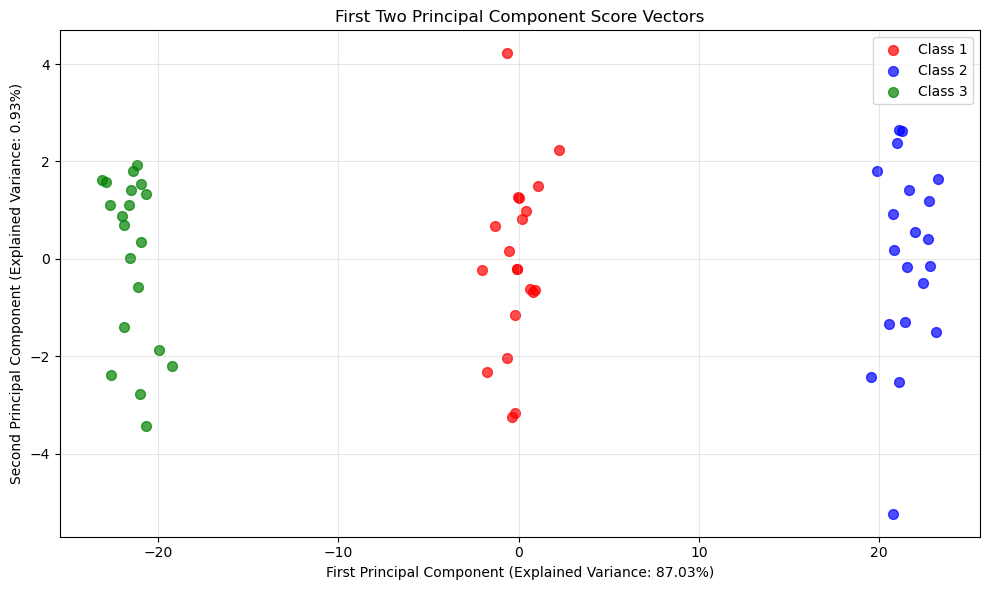

Total variance explained by first two PCs: 87.96%


In [7]:
# Perform PCA on the data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the first two principal component score vectors
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
class_labels = ['Class 1', 'Class 2', 'Class 3']

for i in range(1, n_classes + 1):
    mask = y_true == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i-1], label=class_labels[i-1], 
                alpha=0.7, s=50)

plt.xlabel(f'First Principal Component (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Second Principal Component (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})')
plt.title('First Two Principal Component Score Vectors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display total variance explained by the first two principal components
print(f"Total variance explained by first two PCs: {sum(pca.explained_variance_ratio_):.2%}")

(c) Perform K-means clustering of the observations with K = 3.
 How well do the clusters that you obtained in K-means cluster
ing compare to the true class labels?
 Hint: You can use the pd.crosstab() function in Python to com
pare the true class labels to the class labels obtained by cluster
ing. Be careful how you interpret the results: K-means clustering
 will arbitrarily number the clusters, so you cannot simply check
 whether the true class labels and clustering labels are the same

c:\Users\jerem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\jerem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Crosstab of True Class Labels vs K-means Cluster Labels:
K-means Cluster   0   1   2
True Class                 
1                 0   0  20
2                20   0   0
3                 0  20   0


Clustering Accuracy (with optimal matching): 100.00%
Correctly classified: 60 out of 60


c:\Users\jerem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Crosstab of True Class Labels vs K-means Cluster Labels:
K-means Cluster   0   1   2
True Class                 
1                 0   0  20
2                20   0   0
3                 0  20   0


Clustering Accuracy (with optimal matching): 100.00%
Correctly classified: 60 out of 60


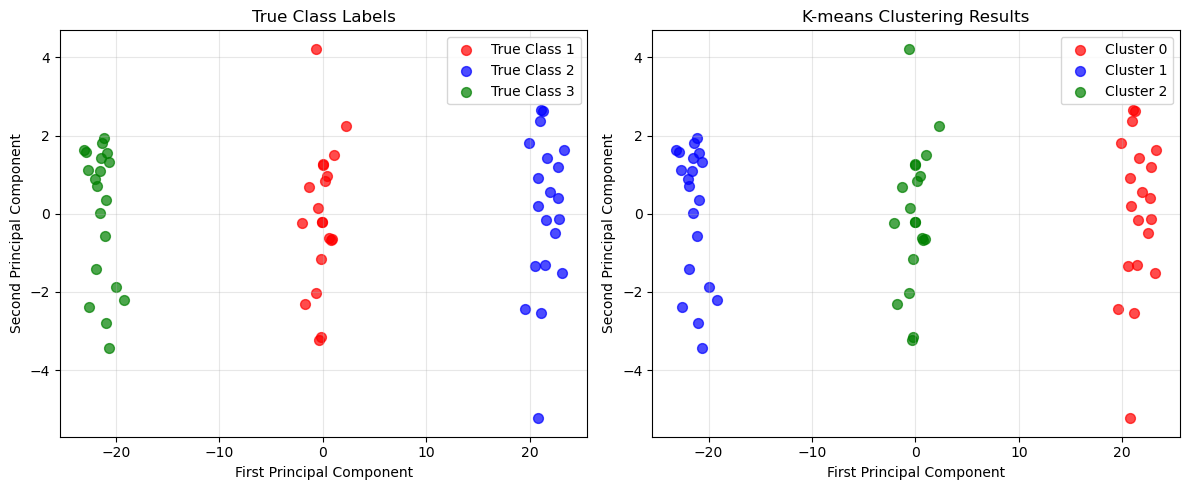

In [13]:
# Perform K-means clustering with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# Create a crosstab to compare true labels with clustering labels
crosstab = pd.crosstab(y_true, y_kmeans, 
                       rownames=['True Class'], 
                       colnames=['K-means Cluster'])
print("Crosstab of True Class Labels vs K-means Cluster Labels:")
print(crosstab)
print("\n")

# Calculate the best match accuracy
from scipy.optimize import linear_sum_assignment

# Create confusion matrix
confusion_matrix = np.zeros((n_classes, n_classes))
for i in range(1, n_classes + 1):
    for j in range(n_classes):
        confusion_matrix[i-1, j] = np.sum((y_true == i) & (y_kmeans == j))

# Find optimal label matching
row_ind, col_ind = linear_sum_assignment(-confusion_matrix)
accuracy = confusion_matrix[row_ind, col_ind].sum() / len(y_true)

print(f"Clustering Accuracy (with optimal matching): {accuracy:.2%}")
print(f"Correctly classified: {int(confusion_matrix[row_ind, col_ind].sum())} out of {len(y_true)}")

# Visualize clustering results
plt.figure(figsize=(12, 5))

# True labels
plt.subplot(1, 2, 1)
for i in range(1, n_classes + 1):
    mask = y_true == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i-1], label=f'True Class {i}', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('True Class Labels')
plt.legend()
plt.grid(True, alpha=0.3)

# K-means clustering
plt.subplot(1, 2, 2)
for i in range(n_classes):
    mask = y_kmeans == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-means Clustering Results')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 (d) Perform K-means clustering with K = 2. Describe your results

c:\Users\jerem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=2 Clustering Results:
Cluster      0   1
True Class        
1            0  20
2           20   0
3            0  20

Cluster 0 contains True Classes: [2]
Cluster 1 contains True Classes: [1 3]


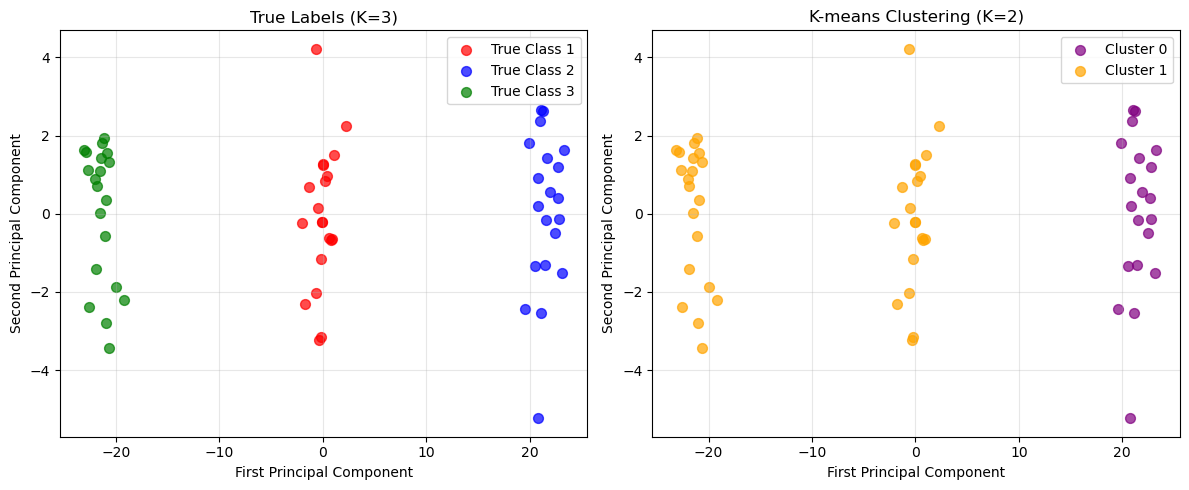


Conclusion: Using K=2 forces the algorithm to merge two of the three
true classes together, demonstrating the importance of choosing the correct K.


In [15]:
# Perform K-means clustering with K=2
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans_k2 = kmeans_k2.fit_predict(X)

# Compare true labels with K=2 clustering
crosstab_k2 = pd.crosstab(y_true, y_kmeans_k2, 
                          rownames=['True Class'], 
                          colnames=['Cluster'])
print("K=2 Clustering Results:")
print(crosstab_k2)
print()

# Analyze cluster composition
for cluster in range(2):
    mask = y_kmeans_k2 == cluster
    classes_in_cluster = np.unique(y_true[mask])
    print(f"Cluster {cluster} contains True Classes: {classes_in_cluster}")

# Visualize comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(1, n_classes + 1):
    mask = y_true == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i-1], label=f'True Class {i}', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('True Labels (K=3)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cluster_colors = ['purple', 'orange']
for i in range(2):
    mask = y_kmeans_k2 == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=cluster_colors[i], label=f'Cluster {i}', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-means Clustering (K=2)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConclusion: Using K=2 forces the algorithm to merge two of the three")
print("true classes together, demonstrating the importance of choosing the correct K.")

 (e) Now perform K-means clustering with K = 4, and describe your
 results.

c:\Users\jerem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=4 Clustering Results:
Cluster      0   1   2  3
True Class               
1            0   0  15  5
2           20   0   0  0
3            0  20   0  0

Cluster 0: 20 observations
Cluster 1: 20 observations
Cluster 2: 15 observations
Cluster 3: 5 observations


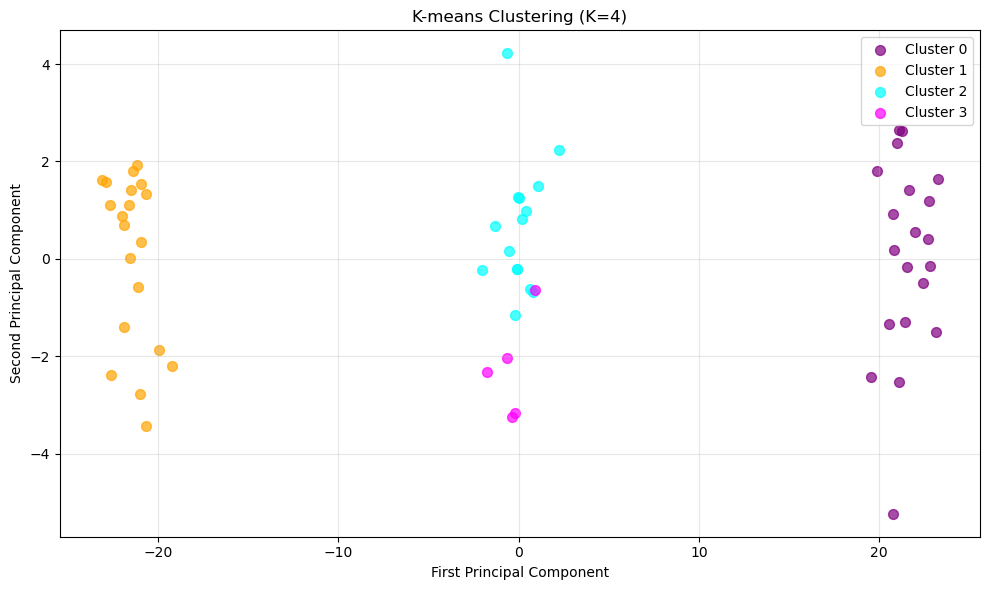


Conclusion: Using K=4 (more than the true number of classes)
causes the algorithm to artificially split one of the true classes,
demonstrating the issue of over-clustering.


In [17]:
# Perform K-means clustering with K=4
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans_k4 = kmeans_k4.fit_predict(X)

# Compare true labels with K=4 clustering
crosstab_k4 = pd.crosstab(y_true, y_kmeans_k4, 
                          rownames=['True Class'], 
                          colnames=['Cluster'])
print("K=4 Clustering Results:")
print(crosstab_k4)
print()

# Analyze cluster composition
for cluster in range(4):
    mask = y_kmeans_k4 == cluster
    n_points = np.sum(mask)
    print(f"Cluster {cluster}: {n_points} observations")

# Visualize K=4 clustering
plt.figure(figsize=(10, 6))
cluster_colors_k4 = ['purple', 'orange', 'cyan', 'magenta']
for i in range(4):
    mask = y_kmeans_k4 == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=cluster_colors_k4[i], label=f'Cluster {i}', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-means Clustering (K=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConclusion: Using K=4 (more than the true number of classes)")
print("causes the algorithm to artificially split one of the true classes,")
print("demonstrating the issue of over-clustering.")


(f) Now perform K-means clustering with K = 3 on the first two
 principal component score vectors, rather than on the raw data.
 That is, perform K-means clustering on the 60 × 2 matrix of
 which the first column is the first principal component score
 vector, and the second column is the second principal component
 score vector. Comment on the results

c:\Users\jerem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-means on First Two Principal Components:
PCA Cluster   0   1   2
True Class             
1             0   0  20
2            20   0   0
3             0  20   0

Clustering Accuracy on PCA (2D): 100.00%
Clustering Accuracy on Raw Data (50D): 100.00%


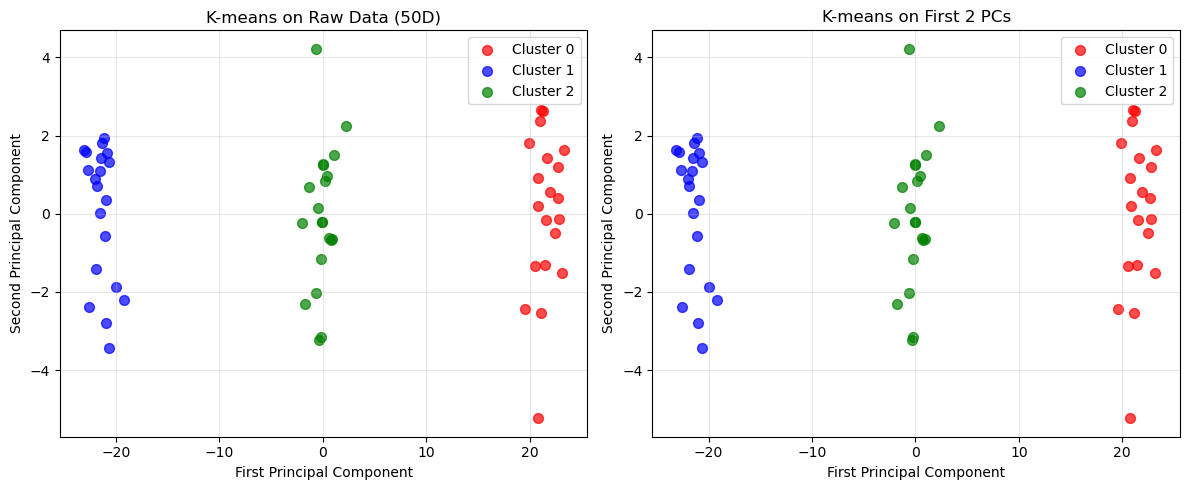


The first two PCs explain 87.96% of variance.
K-means on PCA achieves similar performance with much lower dimensionality.


In [18]:
# Perform K-means clustering with K=3 on the first two principal components
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Compare with true labels
crosstab_pca = pd.crosstab(y_true, y_kmeans_pca, 
                           rownames=['True Class'], 
                           colnames=['PCA Cluster'])
print("K-means on First Two Principal Components:")
print(crosstab_pca)
print()

# Calculate accuracy
confusion_matrix_pca = np.zeros((n_classes, n_classes))
for i in range(1, n_classes + 1):
    for j in range(n_classes):
        confusion_matrix_pca[i-1, j] = np.sum((y_true == i) & (y_kmeans_pca == j))

row_ind_pca, col_ind_pca = linear_sum_assignment(-confusion_matrix_pca)
accuracy_pca = confusion_matrix_pca[row_ind_pca, col_ind_pca].sum() / len(y_true)

print(f"Clustering Accuracy on PCA (2D): {accuracy_pca:.2%}")
print(f"Clustering Accuracy on Raw Data (50D): {accuracy:.2%}")

# Visualize results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(n_classes):
    mask = y_kmeans == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-means on Raw Data (50D)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i in range(n_classes):
    mask = y_kmeans_pca == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.7, s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-means on First 2 PCs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThe first two PCs explain {sum(pca.explained_variance_ratio_):.2%} of variance.")
print("K-means on PCA achieves similar performance with much lower dimensionality.")


 (g) Using the StandardScaler() estimator, perform K-means clus
tering with K = 3 on the data after scaling each variable to have
 standard deviation one. How do these results compare to those
 obtained in (b)? Explain.

c:\Users\jerem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-means on Scaled Data:
Scaled Cluster   0   1   2
True Class                
1                0   0  20
2               20   0   0
3                0  20   0

Scaled Data Accuracy: 100.00%
Original Data Accuracy (part c): 100.00%
Difference: 0.00%


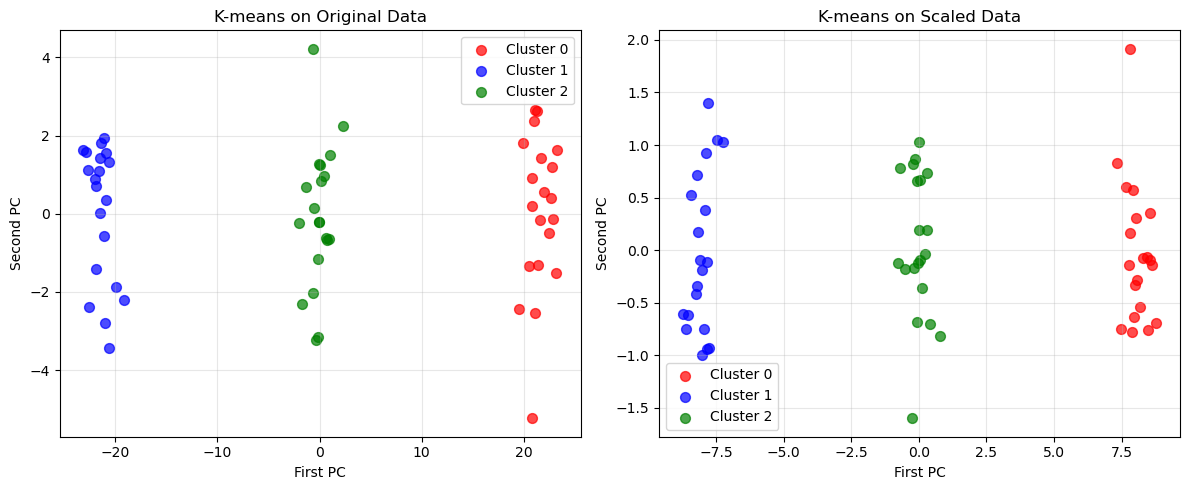


Explanation:
Since our data was generated with the same scale (std=1) for all features,
standardization has minimal impact. In practice, always scale before K-means
to prevent features with larger scales from dominating the distance calculation.


In [19]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform K-means clustering with K=3 on scaled data
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans_scaled = kmeans_scaled.fit_predict(X_scaled)

# Compare with true labels
crosstab_scaled = pd.crosstab(y_true, y_kmeans_scaled, 
                               rownames=['True Class'], 
                               colnames=['Scaled Cluster'])
print("K-means on Scaled Data:")
print(crosstab_scaled)
print()

# Calculate and compare accuracy
confusion_matrix_scaled = np.zeros((n_classes, n_classes))
for i in range(1, n_classes + 1):
    for j in range(n_classes):
        confusion_matrix_scaled[i-1, j] = np.sum((y_true == i) & (y_kmeans_scaled == j))

row_ind_scaled, col_ind_scaled = linear_sum_assignment(-confusion_matrix_scaled)
accuracy_scaled = confusion_matrix_scaled[row_ind_scaled, col_ind_scaled].sum() / len(y_true)

print(f"Scaled Data Accuracy: {accuracy_scaled:.2%}")
print(f"Original Data Accuracy (part c): {accuracy:.2%}")
print(f"Difference: {abs(accuracy_scaled - accuracy):.2%}")

# Visualize comparison
pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(n_classes):
    mask = y_kmeans == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.7, s=50)
plt.xlabel('First PC')
plt.ylabel('Second PC')
plt.title('K-means on Original Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i in range(n_classes):
    mask = y_kmeans_scaled == i
    plt.scatter(X_pca_scaled[mask, 0], X_pca_scaled[mask, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.7, s=50)
plt.xlabel('First PC')
plt.ylabel('Second PC')
plt.title('K-means on Scaled Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Explanation
print("\nExplanation:")
print("Since our data was generated with the same scale (std=1) for all features,")
print("standardization has minimal impact. In practice, always scale before K-means")
print("to prevent features with larger scales from dominating the distance calculation.")
